### Vehicle Routing Problem (VRP)

The Vehicle Routing Problem is a variant of the Traveling Salesman Problem (TSP), in which a set of vehicles must be routed in order to serve all customers. In its simplest version, the problem does not consider customer demands. Let $K$ be the set of vehicles and $C$ the set of customers. We define a binary decision variable $x_{ijk}$ equal to 1 if vehicle $k$ travels from node $i$ to node $j$, and 0 otherwise. The auxiliary variable $u_{ik}$ is used to eliminate subtours through MTZ-type constraints. The problem is defined as follows.

$$
\begin{aligned}
\min \quad & \sum_{k \in K} \sum_{i \in N} \sum_{\substack{j \in N \\ j \ne i}} c_{ij} \, x_{ijk} \\
\text{s.t.} \quad
& \sum_{k \in K} \sum_{\substack{i \in N \\ i \ne j}} x_{ijk} = 1 && \forall j \in C \\
& \sum_{\substack{i \in N \\ i \ne h}} x_{ihk} = \sum_{\substack{j \in N \\ j \ne h}} x_{hjk} && \forall h \in N,\; \forall k \in K \\
& \sum_{j \in C} x_{0jk} = 1 && \forall k \in K \\
& \sum_{j \in C} x_{j0k} = 1 && \forall k \in K \\
& u_{ik} \geq 1,\quad u_{ik} \leq |C| && \forall i \in C,\; \forall k \in K \\
& u_{ik} - u_{jk} + |C| \cdot x_{ijk} \leq |C| - 1 && \forall i \ne j,\; i,j \in C,\; \forall k \in K \\
& x_{ijk} \in \{0,1\} && \forall i,j \in N,\; i \ne j,\; \forall k \in K \\
& u_{ik} \in \mathbb{R}^+ && \forall i \in C,\; \forall k \in K
\end{aligned}
$$


In [1]:
%pip install gurobipy
import gurobipy as gp
from gurobipy import GRB
import itertools
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 57.8 MB/s eta 0:00:00


In [2]:
# Coordinates (0 = depot)
locations = {
    0: (50, 50),  # depot
    1: (20, 30),
    2: (60, 20),
    3: (30, 70),
    4: (80, 40),
    5: (60, 80),
    6: (40, 10)
}

nodes = list(locations.keys())
customers = [i for i in nodes if i != 0]
vehicles = [1, 2]

# Euclidean distances
dist = {
    (i, j): round(((locations[i][0] - locations[j][0]) ** 2 +
                   (locations[i][1] - locations[j][1]) ** 2) ** 0.5)
    for i, j in itertools.permutations(nodes, 2)
}

In [3]:
# Model
m = gp.Model("VRP_Without_Capacity")

# Binary variables: x[i,j,k] = 1 if vehicle k travels from i to j
x = m.addVars(dist.keys(), vehicles, vtype=GRB.BINARY, name="x")

# Variables u[i,k] for MTZ subtour elimination
u = m.addVars(customers, vehicles, vtype=GRB.CONTINUOUS, name="u")

# Objective: minimize total distance
m.setObjective(
    gp.quicksum(dist[i, j] * x[i, j, k] for i, j in dist for k in vehicles),
    GRB.MINIMIZE
)

# Each customer is visited exactly once
for j in customers:
    m.addConstr(gp.quicksum(x[i, j, k] for i in nodes if i != j for k in vehicles) == 1)

# Flow conservation for each node and vehicle
for k in vehicles:
    for h in nodes:
        m.addConstr(
            gp.quicksum(x[i, h, k] for i in nodes if i != h) ==
            gp.quicksum(x[h, j, k] for j in nodes if j != h)
        )

# Each vehicle leaves and returns to the depot
for k in vehicles:
    m.addConstr(gp.quicksum(x[0, j, k] for j in customers) == 1)
    m.addConstr(gp.quicksum(x[j, 0, k] for j in customers) == 1)

# MTZ subtour elimination
for k in vehicles:
    for i in customers:
        m.addConstr(u[i, k] >= 1)
        m.addConstr(u[i, k] <= len(customers))
    for i, j in itertools.permutations(customers, 2):
        m.addConstr(u[i, k] - u[j, k] + len(customers) * x[i, j, k] <= len(customers) - 1)

m.optimize()

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 108 rows, 96 columns and 468 nonzeros (Min)
Model fingerprint: 0xe3d1a5a8
Model has 84 linear objective coefficients
Variable types: 12 continuous, 84 integer (84 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+00]
  Objective range  [2e+01, 7e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 6e+00]

Found heuristic solution: objective 335.0000000
Presolve removed 26 rows and 0 columns
Presolve time: 0.01s
Presolved: 82 rows, 96 columns, 660 nonzeros
Variable types: 12 continuous, 84 integer (84 binary)

Root relaxation: objective 2.320000e+02, 25 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objec

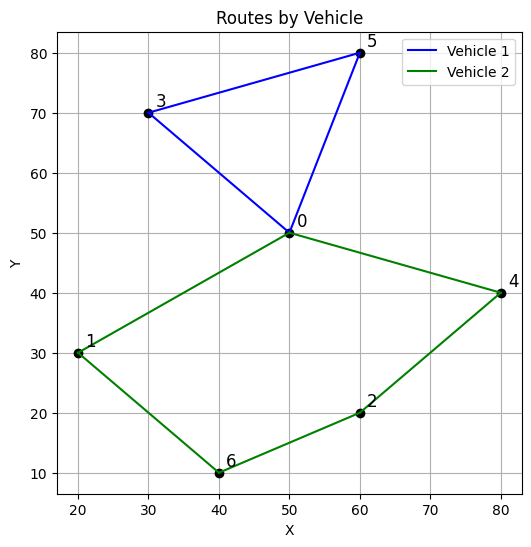

In [4]:
# Retrieve the solutions
routes = {k: [] for k in vehicles}
vals = m.getAttr('X', x)

# Reconstruct routes for each vehicle
for k in vehicles:
    current = 0
    route = [0]
    while True:
        for j in nodes:
            if j != current and vals[current, j, k] > 0.5:
                route.append(j)
                current = j
                break
        if current == 0:
            break
    routes[k] = route

# Function to plot the routes
def plot_routes(locations, routes, title="Routes by Vehicle"):
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    plt.figure(figsize=(6, 6))
    for i in locations:
        x, y = locations[i]
        plt.plot(x, y, 'ko')
        plt.text(x + 1, y + 1, str(i), fontsize=12)

    for k, route in routes.items():
        for i in range(len(route) - 1):
            a, b = route[i], route[i + 1]
            x_coords = [locations[a][0], locations[b][0]]
            y_coords = [locations[a][1], locations[b][1]]
            plt.plot(
                x_coords, y_coords, '-',
                color=colors[k % len(colors)],
                label=f'Vehicle {k}' if i == 0 else ""
            )

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.legend()
    plt.show()

# Plot routes
plot_routes(locations, routes)

In [5]:
import random
import itertools

# Seed
random.seed(10000)

# Nodes (customers plus depot)
n = 18
cities = {i: (random.randint(0, 100), random.randint(0, 100)) for i in range(n)}

# Distance matrix
dist = {
    (i, j): round(((cities[i][0] - cities[j][0]) ** 2 + (cities[i][1] - cities[j][1]) ** 2) ** 0.5)
    for i, j in itertools.permutations(cities, 2)
}

# Nodes
nodes = list(cities.keys())
customers = [i for i in nodes if i != 0]
vehicles = [1, 2, 3, 4, 5]  # You can adjust this number

# Show summary
print(f"Depot: node 0")
print(f"Customers: {len(customers)}")
print(f"Vehicles: {len(vehicles)}")

Depot: node 0
Customers: 17
Vehicles: 5


In [6]:
# Model
m = gp.Model("VRP_Without_Capacity")

# Binary variables: x[i,j,k] = 1 if vehicle k travels from i to j
x = m.addVars(dist.keys(), vehicles, vtype=GRB.BINARY, name="x")

# Variables u[i,k] for MTZ subtour elimination
u = m.addVars(customers, vehicles, vtype=GRB.CONTINUOUS, name="u")

# Objective: minimize total distance
m.setObjective(
    gp.quicksum(dist[i, j] * x[i, j, k] for i, j in dist for k in vehicles),
    GRB.MINIMIZE
)

# Each customer is visited exactly once
for j in customers:
    m.addConstr(gp.quicksum(x[i, j, k] for i in nodes if i != j for k in vehicles) == 1)

# Flow conservation for each node and vehicle
for k in vehicles:
    for h in nodes:
        m.addConstr(
            gp.quicksum(x[i, h, k] for i in nodes if i != h) ==
            gp.quicksum(x[h, j, k] for j in nodes if j != h)
        )

# Each vehicle leaves and returns to the depot
for k in vehicles:
    m.addConstr(gp.quicksum(x[0, j, k] for j in customers) == 1)
    m.addConstr(gp.quicksum(x[j, 0, k] for j in customers) == 1)

# MTZ subtour elimination
for k in vehicles:
    for i in customers:
        m.addConstr(u[i, k] >= 1)
        m.addConstr(u[i, k] <= len(customers))
    for i, j in itertools.permutations(customers, 2):
        m.addConstr(u[i, k] - u[j, k] + len(customers) * x[i, j, k] <= len(customers) - 1)

m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 1647 rows, 1615 columns and 8925 nonzeros (Min)
Model fingerprint: 0x6dce7cbd
Model has 1530 linear objective coefficients
Variable types: 85 continuous, 1530 integer (1530 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [1e+00, 1e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+01]

Presolve removed 175 rows and 0 columns
Presolve time: 0.04s
Presolved: 1472 rows, 1615 columns, 15185 nonzeros
Variable types: 85 continuous, 1530 integer (1530 binary)
Found heuristic solution: objective 1475.0000000

Root relaxation: objective 5.320000e+02, 143 iterations, 0.01 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj

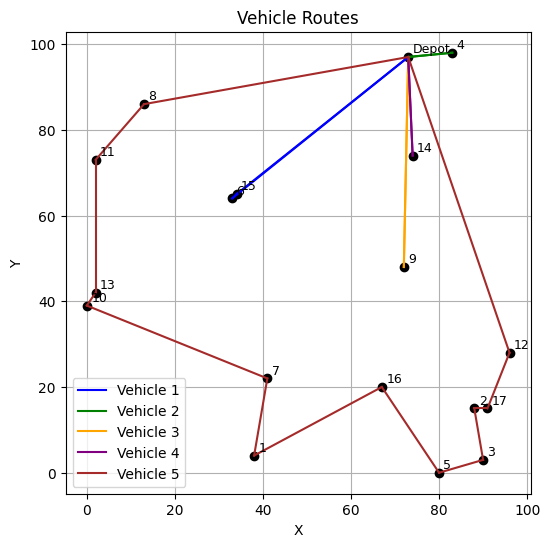

In [7]:
# Retrieve the solutions
routes = {k: [] for k in vehicles}
vals = m.getAttr('X', x)

# Reconstruct routes for each vehicle
for k in vehicles:
    current = 0
    route = [0]
    while True:
        for j in nodes:
            if j != current and vals[current, j, k] > 0.5:
                route.append(j)
                current = j
                break
        if current == 0:
            break
    routes[k] = route

def plot_vrp(cities, routes, title="Vehicle Routes"):
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta']

    plt.figure(figsize=(6, 6))
    for i, coord in cities.items():
        x, y = coord
        plt.plot(x, y, 'ko')
        label = "Depot" if i == 0 else str(i)
        plt.text(x + 1, y + 1, label, fontsize=9)

    for k, route in routes.items():
        color = colors[k % len(colors)]
        for i in range(len(route) - 1):
            a, b = route[i], route[i + 1]
            xa, ya = cities[a]
            xb, yb = cities[b]
            plt.plot([xa, xb], [ya, yb], '-', color=color, label=f"Vehicle {k}" if i == 0 else "")

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_vrp(cities, routes)